# Project Tasks

In the first two assignments, we have learned how to infer part based components (known as mutational signatures) generated by particular mutational processes using Non-negative Matrix Factorization (NMF). By doing this, we are trying to reconstruct the mutation catalog in a given sample with mutational signatures and their contributions.

In this group project, you will use similar mutational profiles and signature activities to predict cancer types but with much larger sample size. 
You should:
* Separate the data into training and test groups within each cancer type.
* Find out which features are informative for the prediction of the cancer type (label). You should try both combining the profiles with activities and using each data type independently.
* Implement different models of your choice for classification of the samples given the input data and evaluate the model performance using test data to avoid overfitting. Explain briefly how does each model that you have used work.
* Report model performance, using standard machine learning metrics such as confusion matrices etc. 
* Compare model performance across methods and across cancer types, are some types easier to predict than others.
* Submit a single Jupyter notebook as the final report and present that during the last assignment session.

# Data

The data include both mutational catalogs from multiple cancers and the predicted activities in the paper ["Alexandrov LB, et al. (2020) The repertoire of mutational signatures in human cancer"](https://www.nature.com/articles/s41586-020-1943-3). The data either are generated from whole human genome (WGS) or only exomes regions (WES). Since the exome region only constitutes about 1% of human genome, the total mutation numbers in these samples are, of course, much smaller. So if you plan to use WGS together with WES data, remember to normalize the profile for each sample to sum up to 1.

Note that, the data is generated from different platforms by different research groups, some of them (e.g. labeled with PCAWG, TCGA) are processed with the same bioinformatics pipeline. Thus, these samples will have less variability related to data processing pipelines.

Cancer types might be labeled under the same tissue, e.g. 'Bone-Benign','Bone-Epith', which can also be combined together or take the one has more samples.

Here is a link to background reading ["Pan-Cancer Analysis of Whole Genomes"](https://www.nature.com/collections/afdejfafdb). Have a look especially at the paper ["A deep learning system accurately classifies primary and metastatic cancers using passenger mutation patterns"](https://www.nature.com/articles/s41467-019-13825-8).

In [1]:
import pandas as pd
import re

## Mutational catalogs and activities - WGS data

In [2]:
## PCAWG data is performed by the same pipeline
PCAWG_wgs_mut = pd.read_csv ("./project_data/catalogs/WGS/WGS_PCAWG.96.csv")
PCAWG_wgs_mut.head(2)

,Mutation type,Trinucleotide,Biliary-AdenoCA::SP117655,Biliary-AdenoCA::SP117556,Biliary-AdenoCA::SP117627,Biliary-AdenoCA::SP117775,Biliary-AdenoCA::SP117332,Biliary-AdenoCA::SP117712,Biliary-AdenoCA::SP117017,Biliary-AdenoCA::SP117031,...,Uterus-AdenoCA::SP94540,Uterus-AdenoCA::SP95222,Uterus-AdenoCA::SP89389,Uterus-AdenoCA::SP90503,Uterus-AdenoCA::SP92460,Uterus-AdenoCA::SP92931,Uterus-AdenoCA::SP91265,Uterus-AdenoCA::SP89909,Uterus-AdenoCA::SP90629,Uterus-AdenoCA::SP95550
0,C>A,ACA,269,114,105,217,52,192,54,196,...,117,233,94,114,257,139,404,97,250,170
1,C>A,ACC,148,56,71,123,36,139,54,102,...,90,167,59,64,268,75,255,78,188,137


Accuracy is the cosine similarity of reconstruct catalog to the observed catalog 

In [12]:
## Activities:
PCAWG_wgs_act = pd.read_csv ("./project_data/activities/WGS/WGS_PCAWG.activities.csv")
PCAWG_wgs_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,Biliary-AdenoCA,SP117655,0.968,1496,1296,0,0,1825,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Biliary-AdenoCA,SP117556,0.963,985,0,0,0,922,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
nonPCAWG_wgs_mut = pd.read_csv ("./project_data/catalogs/WGS/WGS_Other.96.csv")
nonPCAWG_wgs_mut.head(2)

,Mutation type,Trinucleotide,ALL::PD4020a,ALL::SJBALL011_D,ALL::SJBALL012_D,ALL::SJBALL020013_D1,ALL::SJBALL020422_D1,ALL::SJBALL020579_D1,ALL::SJBALL020589_D1,ALL::SJBALL020625_D1,...,Stomach-AdenoCa::pfg316T,Stomach-AdenoCa::pfg317T,Stomach-AdenoCa::pfg344T,Stomach-AdenoCa::pfg373T,Stomach-AdenoCa::pfg375T,Stomach-AdenoCa::pfg378T,Stomach-AdenoCa::pfg398T,Stomach-AdenoCa::pfg413T,Stomach-AdenoCa::pfg416T,Stomach-AdenoCa::pfg424T
0,C>A,ACA,35,9,2,7,5,7,3,5,...,133,185,202,185,96,134,12,279,75,135
1,C>A,ACC,16,2,4,10,5,9,1,2,...,48,70,126,88,35,54,16,112,31,91


In [5]:
nonPCAWG_wgs_act = pd.read_csv ("./project_data/activities/WGS/WGS_Other.activities.csv")
nonPCAWG_wgs_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,ALL,PD4020a,0.995,208,3006,0,0,365,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ALL,SJBALL011_D,0.905,66,0,0,0,144,0,0,...,0,0,0,0,0,0,0,0,0,0


## Mutational catalogs - WES data

In [6]:
## Performed by TCGA pipeline
TCGA_wes_mut = pd.read_csv ("./project_data/catalogs/WES/WES_TCGA.96.csv")
TCGA_wes_mut.head(2)

,Mutation type,Trinucleotide,AML::TCGA-AB-2802-03B-01W-0728-08,AML::TCGA-AB-2803-03B-01W-0728-08,AML::TCGA-AB-2804-03B-01W-0728-08,AML::TCGA-AB-2805-03B-01W-0728-08,AML::TCGA-AB-2806-03B-01W-0728-08,AML::TCGA-AB-2807-03B-01W-0728-08,AML::TCGA-AB-2808-03B-01W-0728-08,AML::TCGA-AB-2809-03D-01W-0755-09,...,Eye-Melanoma::TCGA-WC-A885-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-A888-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-A88A-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-AA9A-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-AA9E-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A980-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A982-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A983-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A984-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A985-01A-11D-A39W-08
0,C>A,ACA,0,0,0,0,4,0,2,0,...,1,0,0,0,0,0,0,0,0,0
1,C>A,ACC,0,2,0,0,0,1,3,0,...,0,0,0,0,0,0,0,1,0,0


In [7]:
##Activities
TCGA_wes_act = pd.read_csv("./project_data/activities/WES/WES_TCGA.activities.csv")
TCGA_wes_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,AML,TCGA-AB-2802-03B-01W-0728-08,0.811,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AML,TCGA-AB-2803-03B-01W-0728-08,0.608,4,0,0,0,7,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
other_wes_mut = pd.read_csv("./project_data/catalogs/WES/WES_Other.96.csv")
other_wes_mut.head(2)

,Mutation type,Trinucleotide,ALL::TARGET-10-PAIXPH-03A-01D,ALL::TARGET-10-PAKHZT-03A-01R,ALL::TARGET-10-PAKMVD-09A-01D,ALL::TARGET-10-PAKSWW-03A-01D,ALL::TARGET-10-PALETF-03A-01D,ALL::TARGET-10-PALLSD-09A-01D,ALL::TARGET-10-PAMDKS-03A-01D,ALL::TARGET-10-PAPJIB-04A-01D,...,Head-SCC::V-109,Head-SCC::V-112,Head-SCC::V-116,Head-SCC::V-119,Head-SCC::V-123,Head-SCC::V-124,Head-SCC::V-125,Head-SCC::V-14,Head-SCC::V-29,Head-SCC::V-98
0,C>A,ACA,0,0,0,1,0,0,0,2,...,0,0,0,0,0,0,0,0,0,1
1,C>A,ACC,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


In [9]:
other_wes_act = pd.read_csv("./project_data/activities/WES/WES_Other.activities.csv")
other_wes_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,ALL,TARGET-10-PAIXPH-03A-01D,0.529,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,ALL,TARGET-10-PAKHZT-03A-01R,0.696,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


## WGS data for prediction of mutation types

In [17]:
from random_forest_example.setup import *
%matplotlib inline

In [18]:
#need to install some modules first so execute this cell
# Install a pip package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 24.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [19]:
from scipy.stats import *

In [20]:
#Some extra packages that are useful in this assignment
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn import decomposition
from sklearn import datasets
from scipy.stats import gaussian_kde

In [21]:
## ploting 96 mutational channels
col_set = ['#0343df','#000000','#e50000','#929591','#3f9b0b','#ff81c0']
col_list = []
for i in range (len(col_set)):
    col_list += [col_set[i]] * 16

def plot_mutationchannels(sig, name=""):
    sns.set(rc={"figure.figsize":(11,2.5)})
    sns.set(style="whitegrid", color_codes=True)

    plt.bar(sig.index, sig, width = 0.5, color = col_list)
    plt.xticks(rotation=90, size = 7, weight='bold')
    plt.title (name, size = 12, weight='bold')
    plt.tight_layout()
    plt.show()

In [22]:
mutation_catalog = pd.read_csv ("./project_data/catalogs/WGS/WGS_PCAWG.96.csv")
mutation_catalog = mutation_catalog.set_index (mutation_catalog['Mutation type'] + "_" + mutation_catalog['Trinucleotide'])

In [23]:
mutation_catalog.shape

(96, 2782)

In [24]:
mutation_catalog.head()

,Mutation type,Trinucleotide,Biliary-AdenoCA::SP117655,Biliary-AdenoCA::SP117556,Biliary-AdenoCA::SP117627,Biliary-AdenoCA::SP117775,Biliary-AdenoCA::SP117332,Biliary-AdenoCA::SP117712,Biliary-AdenoCA::SP117017,Biliary-AdenoCA::SP117031,...,Uterus-AdenoCA::SP94540,Uterus-AdenoCA::SP95222,Uterus-AdenoCA::SP89389,Uterus-AdenoCA::SP90503,Uterus-AdenoCA::SP92460,Uterus-AdenoCA::SP92931,Uterus-AdenoCA::SP91265,Uterus-AdenoCA::SP89909,Uterus-AdenoCA::SP90629,Uterus-AdenoCA::SP95550
C>A_ACA,C>A,ACA,269,114,105,217,52,192,54,196,...,117,233,94,114,257,139,404,97,250,170
C>A_ACC,C>A,ACC,148,56,71,123,36,139,54,102,...,90,167,59,64,268,75,255,78,188,137
C>A_ACG,C>A,ACG,25,13,13,29,8,31,12,15,...,12,29,14,19,51,13,52,14,49,32
C>A_ACT,C>A,ACT,154,70,73,126,31,119,41,122,...,82,213,66,68,271,68,281,80,202,116
C>A_CCA,C>A,CCA,215,63,71,129,30,190,54,133,...,119,188,67,89,307,69,339,204,194,127


### Classification of WGS data with random forest (Mutation catalog)

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [26]:
# Here is an example of how to get the various cancer types
cancer_types = np.array([ s.split(":")[0].split("-")[1] for s in mutation_catalog.columns[2:] ])

In [27]:
pd.unique(cancer_types)

array(['AdenoCA', 'TCC', 'Benign', 'Epith', 'Osteosarc', 'DCIS',
       'LobularCA', 'GBM', 'Medullo', 'Oligo', 'PiloAstro', 'SCC',
       'ChRCC', 'RCC', 'HCC', 'BNHL', 'CLL', 'AML', 'MDS', 'MPN',
       'Endocrine', 'Melanoma', 'Leiomyo', 'Liposarc'], dtype='<U9')

In [28]:
from collections import Counter
Counter(cancer_types)

Counter({'AdenoCA': 1245,
         'HCC': 326,
         'Medullo': 146,
         'RCC': 144,
         'SCC': 123,
         'BNHL': 107,
         'Melanoma': 107,
         'CLL': 95,
         'PiloAstro': 89,
         'Endocrine': 85,
         'MPN': 56,
         'ChRCC': 45,
         'GBM': 41,
         'Osteosarc': 38,
         'TCC': 23,
         'Liposarc': 19,
         'Oligo': 18,
         'Benign': 16,
         'Leiomyo': 15,
         'LobularCA': 13,
         'Epith': 11,
         'AML': 11,
         'MDS': 4,
         'DCIS': 3})

In [40]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(mutation_catalog.iloc[:, 2:].T, cancer_types)

In [41]:
from collections import Counter

In [42]:
# Finally we create a RandomForestClassifier object, which we first train using fit()
model = RandomForestClassifier().fit(X_train, y_train)

# Then we use it to predict data, which we then assess
model.score(X_test, y_test)

0.7654676258992805

<Axes: >

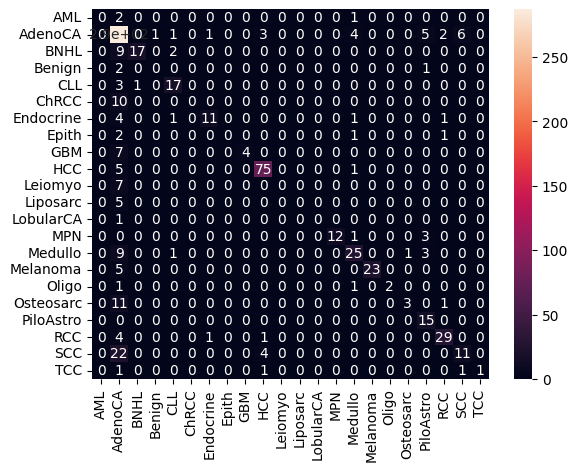

In [43]:
sns.heatmap(
    confusion_matrix(y_test, model.predict(X_test)),
    annot=True,
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test)
)


In [44]:
cm = confusion_matrix(y_test, model.predict(X_test))
print(cm)

[[  0   2   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0
    0   0   0   0]
 [  0 287   0   1   1   0   1   0   0   3   0   0   0   0   4   0   0   0
    5   2   6   0]
 [  0   9  17   0   2   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    1   0   0   0]
 [  0   3   1   0  17   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0  10   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   4   0   0   1   0  11   0   0   0   0   0   0   0   1   0   0   0
    0   1   0   0]
 [  0   2   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0
    0   1   0   0]
 [  0   7   0   0   0   0   0   0   4   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  0   5   0   0   0   0   0   0   0  75   0   0   0   0   1   0   0   0
    0   0   0   0]
 [  0   7   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

In [45]:
#Try again with normalized counts
X = mutation_catalog.iloc[:, 2:].T
X_normalized = X.div(X.sum(axis=1), axis=0)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, cancer_types)
model = RandomForestClassifier().fit(X_train, y_train)
model.score(X_test, y_test)

0.7942446043165468

<Axes: >

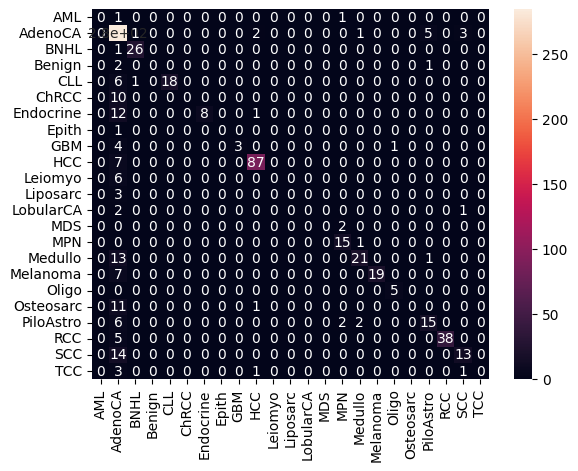

In [46]:
sns.heatmap(
    confusion_matrix(y_test, model.predict(X_test)),
    annot=True,
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test)
)


In [47]:
#Removing the 2 cancer types with loswest counts 
y_series = pd.Series(cancer_types, index=X_normalized.index)

# Remove MDS and DCIS
mask = ~y_series.isin(["MDS", "DCIS"])

X_filtered = X_normalized[mask]
y_filtered = y_series[mask]

In [48]:

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered)
model = RandomForestClassifier().fit(X_train, y_train)
model.score(X_test, y_test)

0.8011527377521613

<Axes: >

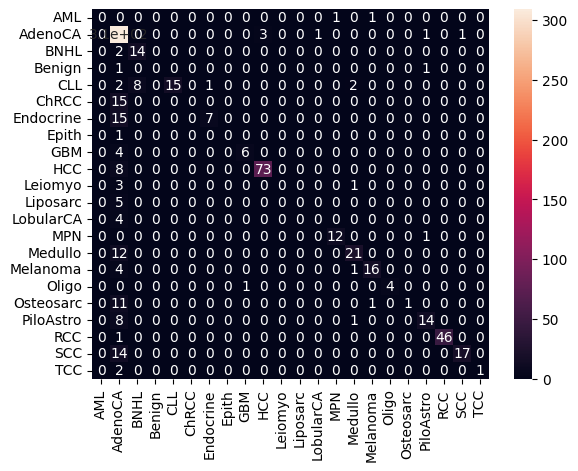

In [49]:
sns.heatmap(
    confusion_matrix(y_test, model.predict(X_test)),
    annot=True,
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test)
)


### Classification of WGS data with Random Forest (mutation activity)

In [50]:
mutation_activities = pd.read_csv("./project_data/activities/WGS/WGS_PCAWG.activities.csv")
mutation_activities.head()


,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,Biliary-AdenoCA,SP117655,0.968,1496,1296,0,0,1825,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Biliary-AdenoCA,SP117556,0.963,985,0,0,0,922,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Biliary-AdenoCA,SP117627,0.973,1110,528,0,0,1453,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Biliary-AdenoCA,SP117775,0.987,1803,1271,0,0,2199,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Biliary-AdenoCA,SP117332,0.987,441,461,0,0,840,0,0,...,0,0,0,0,0,0,0,0,0,0


In [51]:
mutation_activities.shape

(2780, 68)

In [47]:
#get cancer types
cancer_types = np.array([ s.split("-")[0] for s in mutation_activities["Cancer Types"]])
pd.unique(cancer_types)

array(['Biliary', 'Bladder', 'Bone', 'Breast', 'CNS', 'Cervix',
       'ColoRect', 'Eso', 'Head', 'Kidney', 'Liver', 'Lung', 'Lymph',
       'Myeloid', 'Ovary', 'Panc', 'Prost', 'Skin', 'SoftTissue',
       'Stomach', 'Thy', 'Uterus'], dtype='<U10')

In [50]:
X_train, X_test, y_train, y_test = train_test_split(mutation_activities.iloc[:, 3:], cancer_types)

In [51]:
# Finally we create a RandomForestClassifier object, which we first train using fit()
model = RandomForestClassifier().fit(X_train, y_train)

# Then we use it to predict data, which we then assess
model.score(X_test, y_test)

#A lot lower than with mutation catalogue

0.6964028776978417

<Axes: >

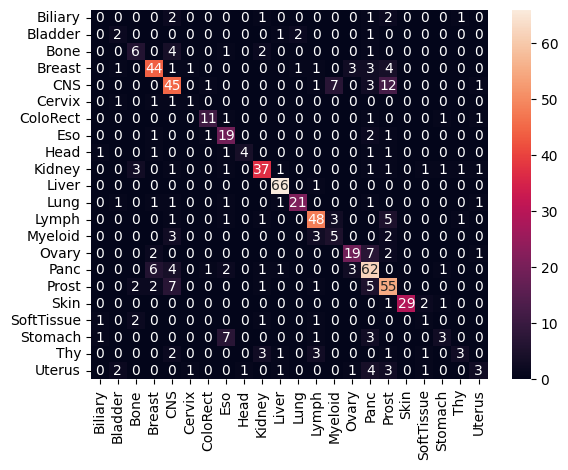

In [53]:
sns.heatmap(
    confusion_matrix(y_test, model.predict(X_test)),
    annot=True,
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test)
)
